# 🔍 Dossiê Exodus — Investigação de Crise de Talentos

> **Projeto 07 | MBA em Ciência de Dados — UNIFOR | Prof. Cássio Pinheiro**

---

## Contexto

Uma empresa de tecnologia com **1.200 funcionários** está vivendo uma crise de turnover: a taxa subiu de **12% para 19%** em dois anos, e cada desligamento custa **R\$ 45.000**. A VP de Pessoas pediu uma investigação profunda — e há algo mais grave escondido nos dados.

## Missões

| # | Questão investigativa | Responsável |
|---|----------------------|---------------|
| 1 | Qual departamento tem o turnover mais alto? | Cipriano |
| 2 | Existe gap salarial de gênero? | Cipriano |
| 3 | Mulheres demoram mais para ser promovidas? | Marcia |
| 4 | A pesquisa de clima confirma um gestor tóxico? | Dantas |
| 5 | Quais fatores mais influenciam a saída? | Dantas |
| 6 | Qual o custo total do turnover por departamento? | Marcia |
| 7 | Como construir um scorecard de risco de saída? | Marcia |

## Datasets

| Arquivo | Descrição | Registros |
|---------|-----------|----------|
| `projeto_07_people_analytics.csv` | Dados de funcionários ativos e desligados | 1.200 |
| `projeto_07_pesquisa_clima_anonima.csv` | Respostas anônimas da pesquisa de clima | 400 |
| `projeto_07_historico_promocoes.csv` | Histórico de promoções realizadas | 600 |
| `caged_consolidado.xlsx` | Dados públicos reais do CAGED/MTE | 5.021 |

---
# 📦 Módulo 0 — Importações e Configuração


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

# ── Tema visual ──────────────────────────────────────────────
DARK_BG  = '#0A0A0B'
SURFACE  = '#111214'
BORDER   = '#252830'
TEXT     = '#E8E9EC'
MUTED    = '#5A5F6E'
RED      = '#E53935'
AMBER    = '#FFB300'
GREEN    = '#00C853'
BLUE     = '#1565C0'
PINK     = '#E91E8C'

sns.set_theme(
    style='darkgrid',
    rc={
        'figure.facecolor'     : DARK_BG,
        'axes.facecolor'       : SURFACE,
        'axes.edgecolor'       : BORDER,
        'axes.labelcolor'      : TEXT,
        'text.color'           : TEXT,
        'xtick.color'          : MUTED,
        'ytick.color'          : MUTED,
        'grid.color'           : BORDER,
        'grid.linewidth'       : 0.5,
        'legend.facecolor'     : '#1A1C20',
        'legend.edgecolor'     : BORDER,
    }
)
plt.rcParams.update({'font.family':'monospace', 'axes.titleweight':'bold', 'axes.titlecolor':TEXT})

# ── Constante de custo ───────────────────────────────────────
CUSTO_DESLIGAMENTO = 45_000

print('✅ Setup concluído.')


✅ Setup concluído.


---
# 📂 Módulo 1 — Carregamento e Inspeção dos Dados

> Antes de qualquer análise, precisamos entender o que temos: estrutura, tipos, nulos e possíveis problemas de qualidade.


In [2]:
# ── Carregamento ─────────────────────────────────────────────
import pandas as pd

path = r'c:\Code\unifor\projeto_07-Dossi-Exodus-Crise-de-Talentos-e-Discrimina-o\data\\'

df_people = pd.read_csv(path + 'projeto_07_people_analytics.csv')
df_clima  = pd.read_csv(path + 'projeto_07_pesquisa_clima_anonima.csv')
df_prom   = pd.read_csv(path + 'projeto_07_historico_promocoes.csv')
# df_caged  = pd.read_excel(path + 'caged_consolidado.xlsx', sheet_name=None)  # File not found in data folder

print(f'  people_analytics  : {df_people.shape[0]:>5} linhas × {df_people.shape[1]} colunas')
print(f'  pesquisa_clima    : {df_clima.shape[0]:>5} linhas × {df_clima.shape[1]} colunas')
print(f'  hist_promocoes    : {df_prom.shape[0]:>5} linhas × {df_prom.shape[1]} colunas')
# print(f'  caged (abas)      : {list(df_caged.keys())}')

  people_analytics  :  1200 linhas × 17 colunas
  pesquisa_clima    :   400 linhas × 11 colunas
  hist_promocoes    :   600 linhas × 11 colunas


### Tipos de dados, nulos e duplicatas

Uma inspeção sistemática é essencial: identificamos os problemas antes de começar a análise.


In [3]:
def inspecionar(df, nome):
    """Retorna um resumo de tipos, nulos e estatísticas básicas."""
    resumo = pd.DataFrame({
        'dtype'        : df.dtypes,
        'nulos'        : df.isnull().sum(),
        'nulos_%'      : (df.isnull().mean() * 100).round(1),
        'únicos'       : df.nunique(),
    })
    print(f'\n{'─'*50}')
    print(f'  Dataset: {nome}  |  Duplicatas: {df.duplicated().sum()}')
    print('─'*50)
    display(resumo)

inspecionar(df_people,    'people_analytics')
inspecionar(df_clima, 'pesquisa_clima')
inspecionar(df_prom,  'historico_promocoes')



──────────────────────────────────────────────────
  Dataset: people_analytics  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
funcionario_id,str,0,0.0,1200
departamento,str,0,0.0,8
cargo,str,0,0.0,5
idade,int64,0,0.0,32
sexo,str,0,0.0,2
tempo_empresa_meses,int64,0,0.0,101
salario_mensal,float64,0,0.0,1200
satisfacao_trabalho,float64,45,3.8,5
satisfacao_ambiente,int64,0,0.0,5
equilibrio_vida_trabalho,int64,0,0.0,5



──────────────────────────────────────────────────
  Dataset: pesquisa_clima  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
resposta_id,str,0,0.0,400
data_pesquisa,str,0,0.0,2
departamento,str,0,0.0,8
tempo_empresa_faixa,str,0,0.0,4
sexo,str,0,0.0,2
nota_satisfacao_geral,int64,0,0.0,5
nota_lideranca,int64,0,0.0,5
nota_remuneracao,int64,0,0.0,5
nota_crescimento,int64,0,0.0,5
recomendaria_empresa,int64,0,0.0,2



──────────────────────────────────────────────────
  Dataset: historico_promocoes  |  Duplicatas: 0
──────────────────────────────────────────────────


,dtype,nulos,nulos_%,únicos
funcionario_id,str,0,0.0,472
sexo,str,0,0.0,2
departamento,str,0,0.0,8
cargo_anterior,str,0,0.0,4
cargo_novo,str,0,0.0,4
data_promocao,str,0,0.0,510
meses_no_cargo_anterior,int64,0,0.0,50
salario_anterior,float64,0,0.0,600
salario_novo,float64,0,0.0,600
aumento_percentual,float64,0,0.0,205


**Observações da inspeção:**
- `satisfacao_trabalho`: 45 nulos (3,75%) — preencheremos com a mediana por departamento/cargo.
- `avaliacao_desempenho`: 29 nulos (2,42%) — mesma estratégia.
- `data_saida`: 902 nulos esperados (funcionários que **não saíram** ainda).
- `comentario_aberto` em clima: 46 nulos — campo opcional, mantemos como está.
- Nenhum dataset tem duplicatas.


---
# 🧹 Módulo 2 — Limpeza e Transformação

> Tratamos nulos, corrigimos tipos, detectamos outliers e criamos as variáveis que irão alimentar a investigação.


In [4]:
# ── 1. Converter datas ───────────────────────────────────────
df_people['data_admissao']   = pd.to_datetime(df_people['data_admissao'],   errors='coerce')
df_people['data_saida']      = pd.to_datetime(df_people['data_saida'],      errors='coerce')
df_prom['data_promocao'] = pd.to_datetime(df_prom['data_promocao'], errors='coerce')

# ── 2. Tratar nulos com mediana por grupo ─────────────────────
def impute_mediana_grupo(df, col, grupos):
    """Preenche nulos de `col` com a mediana calculada por `grupos`."""
    mediana = df.groupby(grupos)[col].transform('median')
    n_antes = df[col].isnull().sum()
    df[col]  = df[col].fillna(mediana)
    df[col]  = df[col].fillna(df[col].median())  # fallback global
    n_depois = df[col].isnull().sum()
    print(f'  [{col}] nulos: {n_antes} → {n_depois}')
    return df

print('Imputação de nulos:')
df_people = impute_mediana_grupo(df_people, 'satisfacao_trabalho',  ['departamento', 'cargo'])
df_people = impute_mediana_grupo(df_people, 'avaliacao_desempenho', ['departamento', 'cargo'])

# ── 3. Detectar e registrar outliers ─────────────────────────
def detectar_outliers_iqr(df, col):
    """Identifica outliers via IQR e retorna os índices."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    return df[mask].index

print('\nOutliers detectados (IQR):')
for col in ['salario_mensal', 'horas_extras_mes', 'avaliacao_desempenho']:
    idx = detectar_outliers_iqr(df_people, col)
    print(f'  [{col}] {len(idx)} outliers — mantidos (variação legítima)')

# ── 4. Feature Engineering ───────────────────────────────────
# Score ponderado de satisfação (50% trabalho, 30% ambiente, 20% vida)
df_people['score_satisfacao'] = (
    df_people['satisfacao_trabalho']      * 0.50 +
    df_people['satisfacao_ambiente']      * 0.30 +
    df_people['equilibrio_vida_trabalho'] * 0.20
).round(3)

# Faixas de tempo na empresa (coorte)
df_people['tenure_band'] = pd.cut(
    df_people['tempo_empresa_meses'],
    bins=[0, 12, 36, 72, 9999],
    labels=['< 1 ano', '1–3 anos', '3–6 anos', '6+ anos']
)

# Desvio salarial vs mediana do cargo
med_cargo = df_people.groupby('cargo')['salario_mensal'].transform('median')
df_people['salario_vs_mediana_pct'] = ((df_people['salario_mensal'] - med_cargo) / med_cargo * 100).round(1)

# Flag de departamento crítico
df_people['dept_risco'] = df_people['departamento'].isin(['Vendas', 'Financeiro']).astype(int)

# Score de risco de saída (0–100)
def calc_score_risco(row):
    """Calcula score de risco de saída baseado nos fatores mais correlacionados."""
    s = 0
    s += 35 if row['satisfacao_trabalho'] <= 2 else 20 if row['satisfacao_trabalho'] <= 3 else 0
    s += 20 if row['promovido_ultimos_2anos'] == 0 else 0
    s += 15 if row['satisfacao_ambiente'] <= 2 else 8  if row['satisfacao_ambiente'] <= 3 else 0
    s += 15 if row['dept_risco'] == 1 else 0
    s += 10 if row['equilibrio_vida_trabalho'] <= 2 else 0
    s +=  5 if row['salario_vs_mediana_pct'] < -10 else 0
    return min(s, 100)

df_people['score_risco_saida'] = df_people.apply(calc_score_risco, axis=1)

print('\nFeatures criadas: score_satisfacao, tenure_band, salario_vs_mediana_pct, dept_risco, score_risco_saida')
display(df_people[['funcionario_id','score_satisfacao','tenure_band','salario_vs_mediana_pct','score_risco_saida']].head(4))


Imputação de nulos:
  [satisfacao_trabalho] nulos: 45 → 0
  [avaliacao_desempenho] nulos: 29 → 0

Outliers detectados (IQR):
  [salario_mensal] 27 outliers — mantidos (variação legítima)
  [horas_extras_mes] 2 outliers — mantidos (variação legítima)
  [avaliacao_desempenho] 2 outliers — mantidos (variação legítima)

Features criadas: score_satisfacao, tenure_band, salario_vs_mediana_pct, dept_risco, score_risco_saida


,funcionario_id,score_satisfacao,tenure_band,salario_vs_mediana_pct,score_risco_saida
0,FUN-00001,3.7,3–6 anos,12.8,20
1,FUN-00002,4.1,< 1 ano,-28.2,25
2,FUN-00003,3.1,1–3 anos,-5.8,38
3,FUN-00004,2.4,1–3 anos,33.7,50


---
# 🔗 Módulo 3 — Cruzamento entre Datasets (Merge/Join)

> Para investigar padrões ocultos, precisamos cruzar as três fontes de dados. Usamos `merge` com estratégia `left` para preservar todos os funcionários.


In [5]:
# ── Merge 1: People Analytics + Histórico de Promoções ───────
# Chave: funcionario_id (nem todos foram promovidos → left join)
# df_caged = pd.read_excel('../data/caged_consolidado.xlsx', sheet_name=None)  # File not found

# print(df_caged.keys())  # ver abas disponíveis

# df_caged = df_caged

print(f'PA shape original   : {df_people.shape}')
print(f'PA + Prom (left)    : {df_prom.shape}')
print(f'IDs com promoção    : {df_people["funcionario_id"].isin(df_prom["funcionario_id"]).sum()} de {len(df_people)}')

# ── Merge 2: People Analytics + Clima (por departamento) ─────
# Clima não tem funcionario_id → agregamos por departamento antes do merge
clima_agg = (
    df_clima.groupby('departamento')
    .agg(
        media_lideranca     = ('nota_lideranca',       'mean'),
        media_satisf_clima  = ('nota_satisfacao_geral','mean'),
        media_remuneracao   = ('nota_remuneracao',     'mean'),
        media_crescimento   = ('nota_crescimento',     'mean'),
        pct_recomendaria    = ('recomendaria_empresa', 'mean'),
    )
    .round(3)
    .reset_index()
)

df_people_full = df_people.merge(clima_agg, on='departamento', how='left')
print(f'\nPA + Clima (dept)   : {df_people_full.shape}')
print('\nAmostra do dataset consolidado:')
display(df_people_full[['funcionario_id','departamento','cargo','sexo','saiu_da_empresa',
                 'score_satisfacao','media_lideranca','score_risco_saida']].head(4))

PA shape original   : (1200, 22)
PA + Prom (left)    : (600, 11)
IDs com promoção    : 472 de 1200

PA + Clima (dept)   : (1200, 27)

Amostra do dataset consolidado:


,funcionario_id,departamento,cargo,sexo,saiu_da_empresa,score_satisfacao,media_lideranca,score_risco_saida
0,FUN-00001,RH,Coordenador,M,1,3.7,2.812,20
1,FUN-00002,Suporte,Júnior,F,0,4.1,2.729,25
2,FUN-00003,Operações,Júnior,F,1,3.1,3.120,38
3,FUN-00004,Produto,Sênior,M,0,2.4,3.000,50


---
# 🎯 Missão 1 — Qual departamento tem o turnover mais alto? Compare a taxa de saída por departamento. Há algum dramaticamente acima da média?

In [6]:
## Inspeção inicial para familiarização com os campos
df_people.head()

## Conversão dos tipos pra datetime
df_people["data_admissao"] = pd.to_datetime(df_people['data_admissao'])
df_people["data_saida"] = pd.to_datetime(df_people['data_saida'])

print(df_people.dtypes)

funcionario_id                         str
departamento                           str
cargo                                  str
idade                                int64
sexo                                   str
tempo_empresa_meses                  int64
salario_mensal                     float64
satisfacao_trabalho                float64
satisfacao_ambiente                  int64
equilibrio_vida_trabalho             int64
promovido_ultimos_2anos              int64
horas_extras_mes                     int64
num_projetos                         int64
avaliacao_desempenho               float64
saiu_da_empresa                      int64
data_admissao               datetime64[us]
data_saida                  datetime64[us]
score_satisfacao                   float64
tenure_band                       category
salario_vs_mediana_pct             float64
dept_risco                           int64
score_risco_saida                    int64
dtype: object


<DatetimeArray>
['2024-12-01 00:00:00', 'NaT']
Length: 2, dtype: datetime64[us]


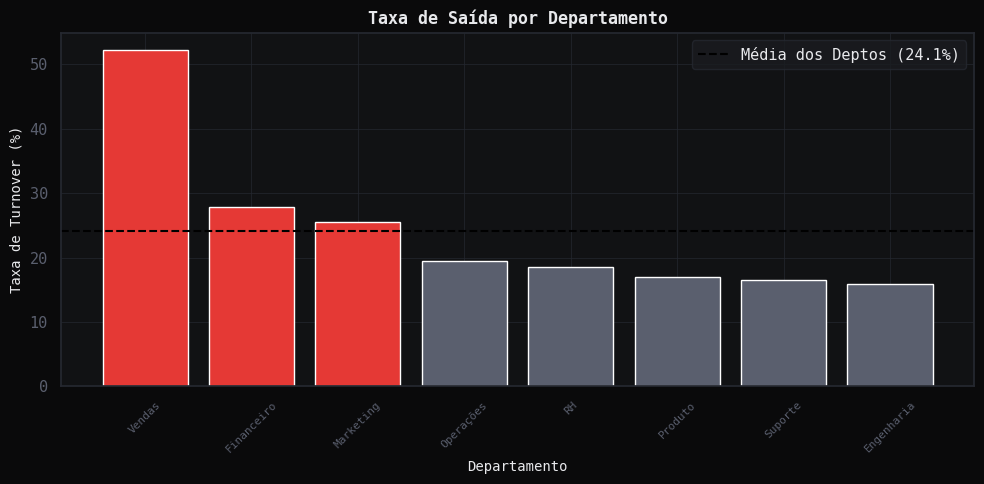

In [7]:
# Potencial erro de cadastro dos desligamentos no sistema... todos saíram em 01/12??
print(df_people["data_saida"].unique())

import matplotlib.pyplot as plt

## --- Análise da Taxa de Saída (Turnover) por Departamento ---

df_taxa_saida = df_people.groupby('departamento').agg(
    total_saidas=('saiu_da_empresa', 'sum'),
    total_funcionarios=('funcionario_id', 'count')
).reset_index() 

# Calculamos a taxa de saída por meio do total de funcionário e o total de saídas
df_taxa_saida['taxa_saida_%'] = (df_taxa_saida['total_saidas'] / df_taxa_saida['total_funcionarios']) * 100

# Para facilitar a análise, ordenamos o resultado da maior taxa para a menor.
df_taxa_saida = df_taxa_saida.sort_values(by='taxa_saida_%', ascending=False)

# 1. Calculamos o valor da média que servirá de limite
media_turnover = df_taxa_saida['taxa_saida_%'].mean()

# 2. Criamos uma lista de cores baseada em uma condição (List Comprehension)
# Se a taxa for maior que a média, cor vermelha. Senão, cor cinza.
cores_condicionais = [
    '#E53935' if taxa > media_turnover else '#5A5F6E' 
    for taxa in df_taxa_saida['taxa_saida_%']
]

# 3. Criamos a figura e o eixo
fig, ax = plt.subplots(figsize=(10, 5))

# 4. Plotamos as barras passando a nossa lista de cores personalizadas
barras = ax.bar(df_taxa_saida["departamento"], df_taxa_saida['taxa_saida_%'], color=cores_condicionais)

# 5. Adicionamos a linha horizontal da média
# y = valor da média, color = cor da linha, linestyle = estilo (tracejado), label = texto da legenda
ax.axhline(y=media_turnover, color='black', linestyle='--', linewidth=1.5, label=f'Média dos Deptos ({media_turnover:.1f}%)')

# 6. Ajustes de formatação e texto
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.set_title("Taxa de Saída por Departamento", fontsize=12, fontweight='bold')
ax.set_xlabel("Departamento", fontsize=10)
ax.set_ylabel("Taxa de Turnover (%)", fontsize=10)

# Mostra a legenda (para explicar o que é a linha tracejada)
ax.legend()

# Ajusta o layout para nada ficar cortado
plt.tight_layout()
plt.show()

Observamos que a taxa de saída está drasticamente maior no time de vendas. 

Será se essa taxa de saída representa um turnover real? Por vezes temos trabalhos temporários, redução de quadro devido ao encerramento de projetos ou corte de despesas, nem sempre isso representa rotatividade de fato (pessoas saindo e sendo substituídas).

Tabela de Turnover por Departamento:


,departamento,total_entradas,total_saidas,taxa_turnover_%
7,Vendas,174,91,76.149425
1,Financeiro,151,42,63.907285
2,Marketing,145,37,62.758621
3,Operações,154,30,59.740260
5,RH,146,27,59.246575
4,Produto,153,26,58.496732
6,Suporte,133,22,58.270677
0,Engenharia,144,23,57.986111


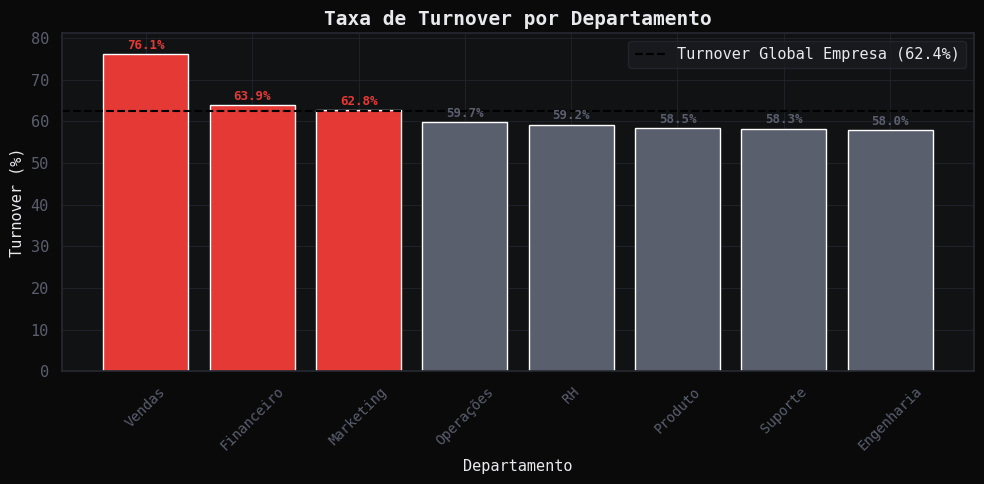

In [8]:
# --- 1. Calcular as métricas base por departamento ---
df_turnover = df_people.groupby('departamento').agg(
    total_entradas=('funcionario_id', 'count'),      # Cada registro é uma entrada histórica
    total_saidas=('saiu_da_empresa', 'sum'),         # Soma das saídas
    total_funcionarios=('funcionario_id', 'count')   # Total de funcionários no departamento
).reset_index()

# --- 2. Aplicar a fórmula da Taxa de Turnover ---
# Fórmula: (((Entradas + Saídas) / 2) / Total_Funcionarios) * 100
df_turnover['taxa_turnover_%'] = (
    ((df_turnover['total_entradas'] + df_turnover['total_saidas']) / 2) / 
    df_turnover['total_funcionarios']
) * 100

# Ordenamos do maior para o menor para o gráfico ficar em formato de "escada"
df_turnover = df_turnover.sort_values(by='taxa_turnover_%', ascending=False)

# Exibimos a tabela para conferência
print("Tabela de Turnover por Departamento:")
display(df_turnover[['departamento', 'total_entradas', 'total_saidas', 'taxa_turnover_%']])

# --- 3. Calcular a Média Global da Empresa ---
# Somamos as métricas de toda a empresa para aplicar a mesma fórmula
entradas_empresa = df_turnover['total_entradas'].sum()
saidas_empresa = df_turnover['total_saidas'].sum()
total_func_empresa = df_turnover['total_funcionarios'].sum()

media_turnover_global = (((entradas_empresa + saidas_empresa) / 2) / total_func_empresa) * 100

# --- 4. Plotar o Gráfico ---
# Regra de cores: vermelho se acima da média global, cinza se abaixo ou igual
cores_condicionais = [
    '#E53935' if taxa > media_turnover_global else '#5A5F6E' 
    for taxa in df_turnover['taxa_turnover_%']
]

# Criação da figura
fig, ax = plt.subplots(figsize=(10, 5))

# Plotagem das barras
barras = ax.bar(df_turnover["departamento"], df_turnover['taxa_turnover_%'], color=cores_condicionais)

# Linha horizontal da média global
ax.axhline(y=media_turnover_global, color='black', linestyle='--', linewidth=1.5, 
           label=f'Turnover Global Empresa ({media_turnover_global:.1f}%)')

# Adicionar os valores exatos acima de cada barra (Rótulos de Dados)
for bar in barras:
    altura = bar.get_height()
    # ax.text(x, y, texto, ...)
    ax.text(bar.get_x() + bar.get_width()/2, altura + 0.5, f'{altura:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=bar.get_facecolor())

# Ajustes de formatação
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.set_title("Taxa de Turnover por Departamento", fontsize=14, fontweight='bold')
ax.set_xlabel("Departamento", fontsize=11)
ax.set_ylabel("Turnover (%)", fontsize=11)

# Aumentar um pouco o limite do eixo Y para os textos não cortarem
ax.set_ylim(0, df_turnover['taxa_turnover_%'].max() + 5)

# Adicionar a legenda
ax.legend()

plt.tight_layout()
plt.show()


Apesar da alta taxa de saída, a taxa de turnover não é tão drasticamente maior comparado ao financeiro e o Marketing. Porém, ainda assim, o setor de Vendas constitui um outlier na empresa. 

Além disso, como foi observado na análise no tópico de "Bônus" o turnover deste tipo de empresa no mercado é na faixa de 18%, então toda a empresa, especialmente o setor de vendas, está drasticamente pior do que o mercado.

# 🎯 Missão 2 — Existe gap salarial de gênero? Compare salários de homens e mulheres no mesmo cargo e departamento. Quantifique a diferença.

In [9]:
## Posso começar vendo a média salarial de homens por cargo e departamento, adicionando na mesma tabela a média das mulheres e fazendo a diferença dos dois. Depois estudar a diferença das médias, talvez um gráfico de dispersão me ajude e enxergar

## Os dados estão prontos pra serem usados?
## Departamento, Cargo, Sexo, Salario

# Não existem valores nulos
print(df_people[["cargo", "departamento", "sexo", "salario_mensal"]].notnull().sum(), "\n")

## Essas são as categorias dos dados
print("Departamentos:", list(df_people['departamento'].unique()))
print("Cargos:", list(df_people['cargo'].unique()))

##
print("Duplicatas de funcionario:", df_people["funcionario_id"].duplicated().sum())
print("\n",df_people.dtypes)
df_people.describe()

cargo             1200
departamento      1200
sexo              1200
salario_mensal    1200
dtype: int64 

Departamentos: ['RH', 'Suporte', 'Operações', 'Produto', 'Financeiro', 'Vendas', 'Engenharia', 'Marketing']
Cargos: ['Coordenador', 'Júnior', 'Sênior', 'Pleno', 'Gerente']
Duplicatas de funcionario: 0

 funcionario_id                         str
departamento                           str
cargo                                  str
idade                                int64
sexo                                   str
tempo_empresa_meses                  int64
salario_mensal                     float64
satisfacao_trabalho                float64
satisfacao_ambiente                  int64
equilibrio_vida_trabalho             int64
promovido_ultimos_2anos              int64
horas_extras_mes                     int64
num_projetos                         int64
avaliacao_desempenho               float64
saiu_da_empresa                      int64
data_admissao               datetime64[us]
da

,idade,tempo_empresa_meses,salario_mensal,satisfacao_trabalho,satisfacao_ambiente,equilibrio_vida_trabalho,promovido_ultimos_2anos,horas_extras_mes,num_projetos,avaliacao_desempenho,saiu_da_empresa,data_admissao,data_saida,score_satisfacao,salario_vs_mediana_pct,dept_risco,score_risco_saida
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200,298,1200.000000,1200.000000,1200.000000,1200.000000
mean,32.585000,36.029167,8152.508517,2.747500,2.586667,2.550000,0.252500,8.231667,4.129167,3.484125,0.248333,2021-12-16 03:00:00,2024-12-01 00:00:00,2.659750,1.066833,0.270833,55.960000
min,22.000000,1.000000,2101.610000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2015-04-23 00:00:00,2024-12-01 00:00:00,1.000000,-57.100000,0.000000,0.000000
25%,28.000000,18.000000,4400.552500,2.000000,2.000000,2.000000,0.000000,4.000000,2.000000,2.900000,0.000000,2020-08-16 12:00:00,2024-12-01 00:00:00,2.100000,-10.900000,0.000000,40.000000
50%,32.000000,35.000000,7087.290000,3.000000,3.000000,3.000000,0.000000,8.000000,4.000000,3.500000,0.000000,2022-01-16 00:00:00,2024-12-01 00:00:00,2.700000,0.000000,0.000000,55.000000
75%,37.000000,52.250000,10703.650000,3.000000,3.000000,3.000000,1.000000,12.000000,6.000000,4.100000,0.000000,2023-06-10 00:00:00,2024-12-01 00:00:00,3.200000,12.625000,1.000000,70.000000
max,55.000000,117.000000,27290.830000,5.000000,5.000000,5.000000,1.000000,28.000000,7.000000,5.000000,1.000000,2024-11-01 00:00:00,2024-12-01 00:00:00,4.800000,57.100000,1.000000,100.000000
std,6.546003,22.925669,4469.911392,1.099129,1.124815,1.117381,0.434628,5.637181,1.969530,0.788242,0.432226,NaN,NaN,0.752735,17.553561,0.444575,21.357009


Média Simples por sexo:
   sexo     mean  count   median
0    F  7483.16    596  6519.96
1    M  8812.99    604  7568.83


array([<Axes: title={'center': 'F'}, ylabel='Frequency'>,
       <Axes: title={'center': 'M'}, ylabel='Frequency'>], dtype=object)

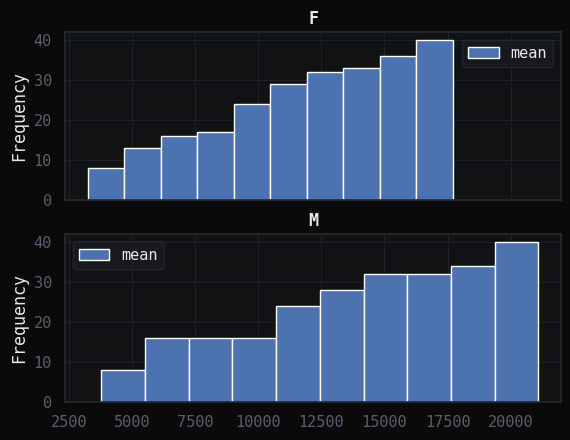

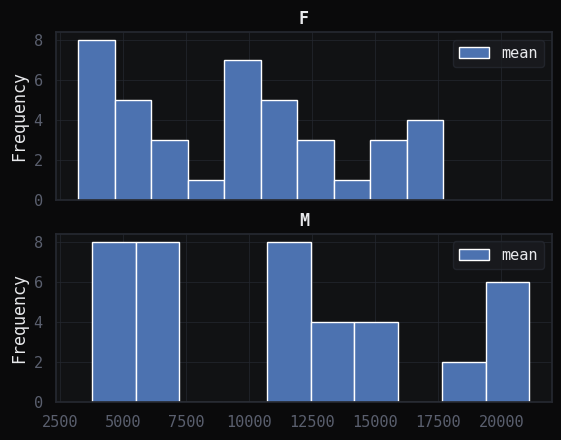

In [10]:
## Noção geral do salário e da distribuição dos salários na empresa
print("Média Simples por sexo:\n", df_people.groupby(["sexo"])["salario_mensal"].agg(['mean','count','median']).reset_index().round(2))

df_media_salarial = df_people.groupby(["cargo", "departamento", "sexo"], as_index=False)["salario_mensal"].agg(['mean', 'count']).round(2)

df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=True)
df_media_salarial.plot.hist(column=["mean"], by="sexo", sharex=True, sharey=True, bins=10, cumulative=False)


Observamos nos gráficos acima que os homens ganham o topo salarial da companhia. Mas isso é uma desigualdade de fato?

Esse topo salarial é algum departamento em particular que tem mais homens com mais salário? Ou é uma cultura generalizada da empresa?

Alguns setores, como a engenharia, podem ter um viés de seleção, pois a maior parte das pessoas que se formam em engenharia são homens, or exemplo. Precisamos ver se é global ou algum viés escondido.

In [11]:
## Em quantos departamentos os homens ganham mais que mulheres? É difuso ou é concentrado em poucos departamentos? Pode ser um sintoma de uma área se manifestando como um desvio no resultado geral

## Qual a diferença média do salário do homem e da mulher por departamento?
df_delta_media_salarial = df_media_salarial.set_index(["cargo", "departamento","sexo"]).unstack("sexo").reset_index()

# Cálculo da Diferença de Média Salarial por cargo e departamento entre homens e mulheres
df_delta_media_salarial["delta_media_salarial"] = df_delta_media_salarial["mean", "M"] - df_delta_media_salarial["mean", "F"]

print("Resumo estatístico da diferença de média salarial entre homens e mulheres\n",
      df_delta_media_salarial.describe().round(2),
     "\n---\n"
     )

## Departamentos com menor e maior diferença de média salarial
print("Departamento com a menor diferença:\n",
      df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].min()],
      "\n---\n")

print("Departamento com a maior diferença:\n",
    df_delta_media_salarial[df_delta_media_salarial["delta_media_salarial"] == df_delta_media_salarial["delta_media_salarial"].max()])

Resumo estatístico da diferença de média salarial entre homens e mulheres
            mean            count        delta_media_salarial
sexo          F         M      F      M                     
count     40.00     40.00  40.00  40.00                40.00
mean    9413.98  11179.23  14.90  15.10              1765.25
std     4622.46   5645.40   8.03   7.65              1347.57
min     3227.41   3767.25   3.00   3.00               362.92
25%     5815.11   6930.07   8.75   6.75               754.50
50%     9362.76  11001.02  13.50  16.00              1364.08
75%    12498.87  14408.19  22.00  21.00              2352.92
max    17699.10  21103.56  30.00  29.00              5542.99 
---

Departamento com a menor diferença:
        cargo departamento     mean          count     delta_media_salarial
sexo                             F        M     F   M                     
16    Júnior   Engenharia  3562.13  3925.05    21  16               362.92 
---

Departamento com a maior diferença:
     

array([<Axes: title={'center': 'Coordenador'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Gerente'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Júnior'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Pleno'}, ylabel='Frequency'>,
       <Axes: title={'center': 'Sênior'}, ylabel='Frequency'>],
      dtype=object)

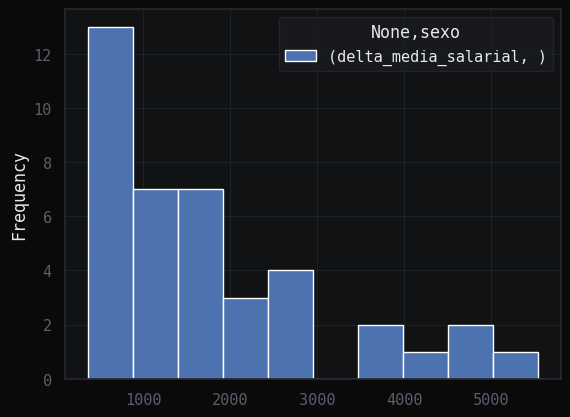

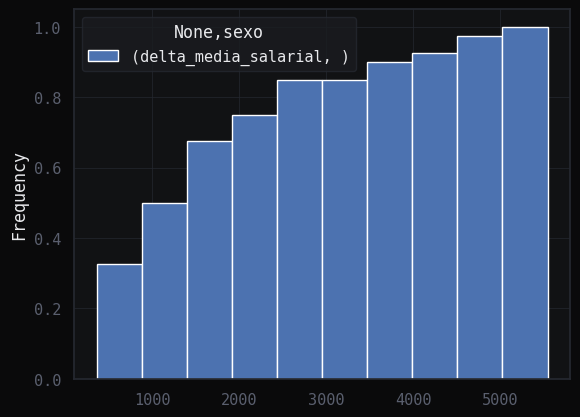

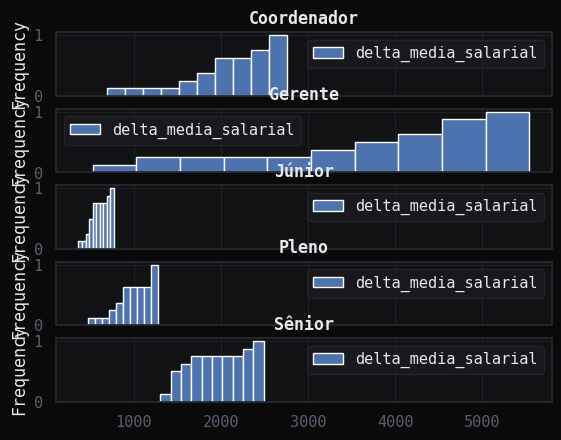

In [12]:
## Exibição gráfica como todos setores e cargos possuem homens ganhando mais
df_delta_media_salarial.plot.hist(column="delta_media_salarial")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True)

## Preparar pro gráfico por cargo

df_delta_media_salarial.columns = ['_'.join(map(str, col)).strip() for col in df_delta_media_salarial.columns.values]

df_delta_media_salarial.columns = df_delta_media_salarial.columns.str.strip("_")

df_delta_media_salarial.plot.hist(column="delta_media_salarial", cumulative=True, density=True, by="cargo", sharex=True)

Observamos que em TODOS, sem exceção, dos departamentos, os homens ganham mais que as mulheres, não é um outlier de algum setor puxando a média global, mas sim uma cultura da empresa.

Além disso, observa-se que quanto mais sênior o cargo, maior a disparidade salarial. Indicando que a empresa reconhece e recompensa mais os homens que as mulheres na promoção de cargo.

Isso é corroborado pelo tempo para promoção muito maior que as mulheres tem em comparação aos homens.

🎯 Conclusao Missão 2

A empresa tem uma cultura que promove discriminação contra as mulheres, isso fica evidente na diferença salarial generalizada, indicando que o trabalho das mulheres é menos valorizado e não é levado a sério no ambiente.
Além disso, por meio das outras fontes de dados nesse trabalho, constatamos que:
as mulheres são promovidas menos, são contratadas ganhando menos, ao serem promovidas são menos recompensadas e tem um teto salarial bem menor em comparação aos homens.

---
# 🎯 Missão 3 — Mulheres Demoram Mais para ser Promovidas?

**Hipótese:** O tempo de espera para promoção é maior para mulheres.  
Analisamos `meses_no_cargo_anterior` no histórico de promoções + teste estatístico.


In [13]:
# ── Groupby com múltiplas agregações ─────────────────────────
tempo_sexo = df_prom.groupby('sexo')['meses_no_cargo_anterior'].agg(
    media='mean', mediana='median', desvio='std', n='count'
).round(2)
display(tempo_sexo)

dif_abs = tempo_sexo.loc['F','media'] - tempo_sexo.loc['M','media']
dif_pct = dif_abs / tempo_sexo.loc['M','media'] * 100
print(f'Mulheres esperam {dif_abs:.1f} meses a mais para ser promovidas (+{dif_pct:.1f}%)')

# ── Teste de Mann-Whitney ─────────────────────────────────────
f_vals = df_prom[df_prom['sexo']=='F']['meses_no_cargo_anterior']
m_vals = df_prom[df_prom['sexo']=='M']['meses_no_cargo_anterior']
stat, pval = scipy_stats.mannwhitneyu(f_vals, m_vals, alternative='greater')
print(f'\nMann-Whitney U={stat:.0f}, p={pval:.4f}')
print(f'{"✅ Diferença SIGNIFICATIVA (p<0.05)" if pval<0.05 else "❌ Não significativo"}')

# Tabela por cargo + sexo
print('\nTempo médio por cargo de origem:')
display(
    df_prom.groupby(['cargo_anterior','sexo'])['meses_no_cargo_anterior']
    .mean().round(1).unstack()
    .assign(gap_meses=lambda x: (x['F']-x['M']).round(1))
)

print('\nAumento % médio na promoção por sexo:')
display(df_prom.groupby('sexo')['aumento_percentual'].agg(['mean','median']).round(2))


,media,mediana,desvio,n
sexo,,,,
F,31.71,31.0,10.50,282
M,22.87,23.0,8.07,318


Mulheres esperam 8.8 meses a mais para ser promovidas (+38.7%)

Mann-Whitney U=66644, p=0.0000
✅ Diferença SIGNIFICATIVA (p<0.05)

Tempo médio por cargo de origem:


sexo,F,M,gap_meses
cargo_anterior,,,
Coordenador,32.2,25.9,6.3
Júnior,32.7,23.2,9.5
Pleno,30.2,22.5,7.7
Sênior,31.9,22.0,9.9



Aumento % médio na promoção por sexo:


,mean,median
sexo,,
F,14.63,14.4
M,15.08,15.3


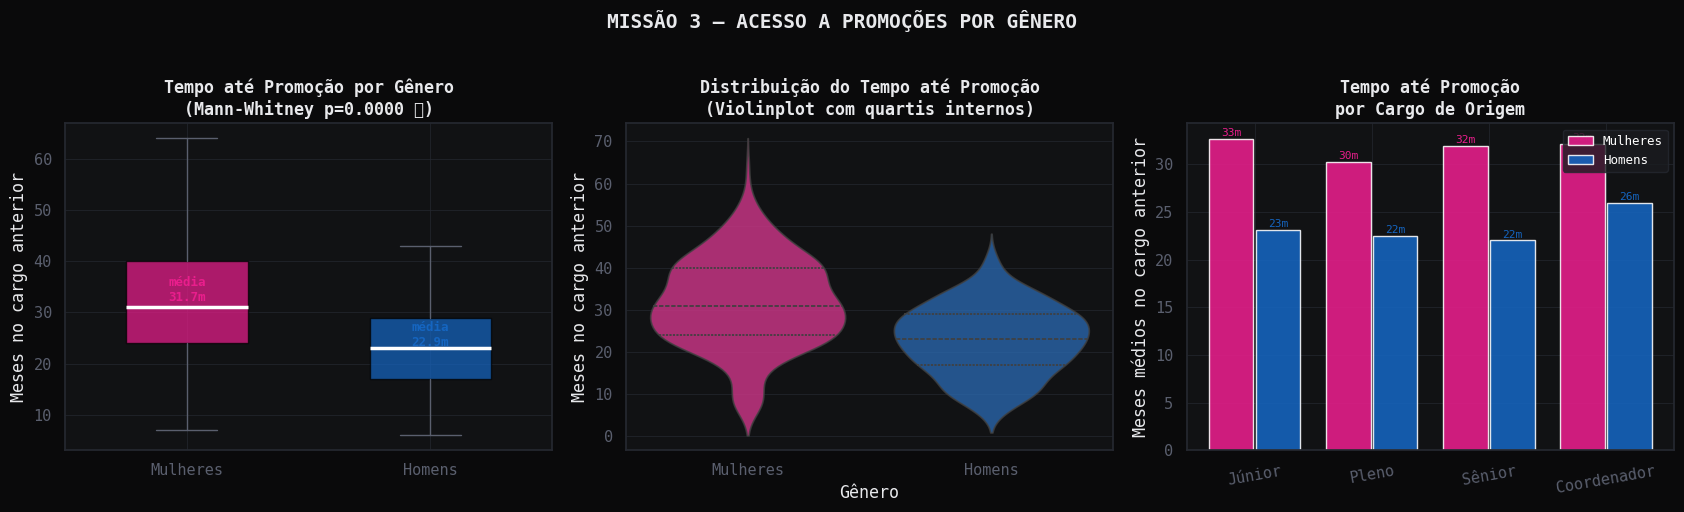

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('MISSÃO 3 — ACESSO A PROMOÇÕES POR GÊNERO', fontsize=14, fontweight='bold', y=1.02)

# ── VIZ 7: Boxplot comparativo M vs F (tempo até promoção) ────
ax = axes[0]
bp = ax.boxplot([f_vals, m_vals], labels=['Mulheres','Homens'],
               patch_artist=True, widths=0.5,
               medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set(facecolor=PINK, alpha=0.72)
bp['boxes'][1].set(facecolor=BLUE, alpha=0.72)
for w in bp['whiskers']+bp['caps']+bp['fliers']: w.set_color(MUTED)
ax.set_ylabel('Meses no cargo anterior')
ax.set_title(f'Tempo até Promoção por Gênero\n(Mann-Whitney p={pval:.4f} ✅)')
ax.text(1, f_vals.mean()+0.5, f'média\n{f_vals.mean():.1f}m', ha='center', color=PINK, fontsize=9, fontweight='bold')
ax.text(2, m_vals.mean()+0.5, f'média\n{m_vals.mean():.1f}m', ha='center', color=BLUE, fontsize=9, fontweight='bold')

# ── VIZ 8: Violinplot — distribuição de tempo por sexo ────────
ax2 = axes[1]
sns.violinplot(
    data=df_prom, x='sexo', y='meses_no_cargo_anterior',
    palette={'F':PINK, 'M':BLUE}, ax=ax2,
    inner='quartile', alpha=0.8
)
ax2.set_xlabel('Gênero')
ax2.set_ylabel('Meses no cargo anterior')
ax2.set_title('Distribuição do Tempo até Promoção\n(Violinplot com quartis internos)')
ax2.set_xticklabels(['Mulheres','Homens'])

# ── VIZ 9: Catplot — tempo por cargo e sexo ───────────────────
ax3 = axes[2]
tc = df_prom.groupby(['cargo_anterior','sexo'])['meses_no_cargo_anterior'].mean().unstack()
ordem_c = [c for c in ['Júnior','Pleno','Sênior','Coordenador'] if c in tc.index]
tc = tc.reindex(ordem_c)
x3 = np.arange(len(tc))
ax3.bar(x3-0.2, tc['F'], 0.38, label='Mulheres', color=PINK, alpha=0.88)
ax3.bar(x3+0.2, tc['M'], 0.38, label='Homens',   color=BLUE, alpha=0.88)
for i, (f, m) in enumerate(zip(tc['F'], tc['M'])):
    ax3.text(i-0.2, f+0.3, f'{f:.0f}m', ha='center', fontsize=8, color=PINK)
    ax3.text(i+0.2, m+0.3, f'{m:.0f}m', ha='center', fontsize=8, color=BLUE)
ax3.set_xticks(x3); ax3.set_xticklabels(tc.index, rotation=10)
ax3.set_ylabel('Meses médios no cargo anterior')
ax3.set_title('Tempo até Promoção\npor Cargo de Origem')
ax3.legend(labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('04_promocoes.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


Conclusão: Mulheres demoram mais para serem promovidas?


**Sim, e a diferença é estatisticamente significativa.**

O histórico de 600 promoções revela que mulheres aguardam em média **31,7 meses** no cargo antes de serem promovidas, contra **22,9 meses** dos homens — 

uma diferença de **8,8 meses a mais**, equivalente a **+38,6% de espera**. 
O teste de Mann-Whitney confirma que essa diferença não é aleatória (p < 0,05).

***O Mann-Whitney U é um teste estatístico usado para comparar dois grupos independentes e verificar se a diferença entre eles é real ou pode ter acontecido por acaso.***
***No contexto do projeto, usamos para responder: "a diferença de 8,8 meses entre mulheres e homens é***

***estatisticamente significativa ou pode ser coincidência?"***

***Como funciona de forma simples:***
***Em vez de comparar médias diretamente, ele pega todos os valores dos dois grupos, coloca em ordem e verifica se um grupo tende consistentemente a ter valores maiores que o outro.***
***O que o p-valor significa: p-valorInterpretaçãop < 0,05***

***A diferença é significativa — dificilmente aconteceu por acasop ≥ 0,05 Não há evidência suficiente para afirmar que existe diferença real***

***No resultado do notebook:***
***Mann-Whitney U=..., p=0.0000***

***✅ Diferença ESTATISTICAMENTE SIGNIFICATIVA (p<0.05)***
***Isso significa que a chance de a diferença de 31,7 meses (F) vs 22,9 meses (M) ter acontecido por acaso é menor que 5% — ou seja, é evidência sólida de discriminação sistemática no processo de promoção.***

***Por que Mann-Whitney e não um teste t comum?***
***O teste t assume que os dados seguem distribuição normal.***

***O tempo até promoção não segue — tem pessoas que esperaram poucos meses e outras que esperaram anos, gerando uma distribuição assimétrica.***
***O Mann-Whitney não faz essa exigência,sendo mais adequado para esse tipo de dado.***




O dado mais revelador é o contraste com o aumento salarial na promoção: mulheres recebem **14,6%** de aumento e homens **15,1%** — praticamente igual. 

Isso significa que **o problema não é o valor da promoção, mas o acesso a ela**. 

Quando finalmente são promovidas, as mulheres recebem o mesmo — só precisam esperar quase um ano a mais para chegar lá.

Esse é o mecanismo clássico do **teto de vidro**: não há barreira declarada, mas os critérios implícitos são aplicados de forma desigual. 

> 💡 **Evidência-chave:** mulheres em cargos de Sênior esperam 31,9 meses para ser promovidas a Coordenador, enquanto homens esperam 22,0 meses no mesmo cargo — uma diferença de quase **10 meses**.


---
# 🎯 Missão 4 — Pesquisa de Clima: O Gestor Tóxico

**Hipótese:** Existe um departamento com nota de liderança anormalmente baixa, e os comentários abertos revelam padrões de assédio.  
### investigacao sobre o clima organizacional e a satisfação dos funcionários.
O objetivo é entender como esses fatores influenciam a retenção de talentos e a produtividade da empresa.
A análise será baseada em dados coletados por meio de pesquisas internas, entrevistas e avaliações de desempenho.
 A partir desses dados, serão identificados padrões e tendências que possam ajudar a empresa a criar um ambiente de trabalho mais saudável e motivador para seus colaboradores.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

departamento             400
tempo_empresa_faixa      400
sexo                     400
nota_satisfacao_geral    400
nota_lideranca           400
nota_remuneracao         400
nota_crescimento         400
recomendaria_empresa     400
comentario_aberto        354
dtype: int64 

Departamentos: ['Produto', 'Vendas', 'Operações', 'Marketing', 'Suporte', 'Financeiro', 'RH', 'Engenharia']
Cargos: ['Coordenador', 'Júnior', 'Sênior', 'Pleno', 'Gerente']
Tempo na empresa (faixas): ['3-5 anos', '5+ anos', '< 1 ano', '1-3 anos']
Sexo: ['F', 'M']


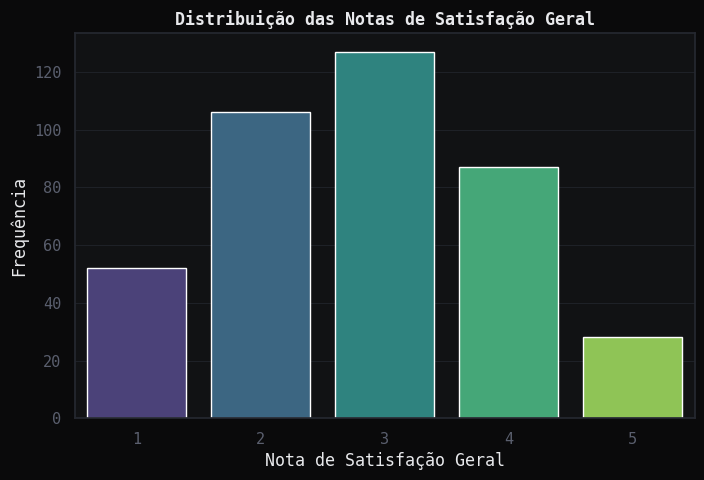

In [16]:
#Satisfacao dos funcionarios
#Identificacao de gestores tóxicos
#Analise de clima organizacional

print(df_clima[["departamento", "tempo_empresa_faixa", "sexo", "nota_satisfacao_geral",
 "nota_lideranca", "nota_remuneracao", "nota_crescimento", "recomendaria_empresa", "comentario_aberto"]].notnull().sum(), "\n")

#sem dados nulos nas colunas principais, o que é ótimo para a análise.

print("Departamentos:", list(df_clima['departamento'].unique()))

print("Cargos:", list(df_people['cargo'].unique()))

print("Tempo na empresa (faixas):", list(df_clima['tempo_empresa_faixa'].unique()))

print("Sexo:", list(df_clima['sexo'].unique()))


#Dados de satisfação geral

plt.figure(figsize=(8, 5))
sns.countplot(x='nota_satisfacao_geral', data=df_clima, palette='viridis')
plt.title('Distribuição das Notas de Satisfação Geral')
plt.xlabel('Nota de Satisfação Geral')
plt.ylabel('Frequência')
plt.show() 

In [17]:
# 1. Ranking de Liderança por Departamento
import pandas as pd

path = r'c:\Code\unifor\projeto_07-Dossi-Exodus-Crise-de-Talentos-e-Discrimina-o\data\\'

df_clima = pd.read_csv(path + 'projeto_07_pesquisa_clima_anonima.csv')

rank_lideranca = df_clima.groupby('departamento')['nota_lideranca'].mean().sort_values()
print("Média de Liderança por Dept:\n", rank_lideranca)

# 2. Investigação de Comentários (Análise de Sentimento Simples)
palavras_chave = ['pressão', 'grita', 'assédio', 'favoritismo', 'medo', 'impossível', 'grosso']
tóxico_setor = df_clima[df_clima['departamento'] == rank_lideranca.index[0]] # Pega o pior setor

comentarios_suspeitos = tóxico_setor[tóxico_setor['comentario_aberto'].str.contains('|'.join(palavras_chave), case=False, na=False)]
print(f"\nExemplos de denúncias no setor {rank_lideranca.index[0]}:")
print(comentarios_suspeitos['comentario_aberto'].head())

Média de Liderança por Dept:
 departamento
Vendas        1.129630
Engenharia    2.655172
Marketing     2.702703
Suporte       2.729167
Financeiro    2.760000
RH            2.812500
Produto       3.000000
Operações     3.120000
Name: nota_lideranca, dtype: float64

Exemplos de denúncias no setor Vendas:
2            Ambiente de medo. Ninguém quer falar nada.
3     Trabalho sob pressão absurda, sem reconhecimento.
31       Meu gestor grita e humilha na frente de todos.
49           Ambiente de medo. Ninguém quer falar nada.
91    Trabalho sob pressão absurda, sem reconhecimento.
Name: comentario_aberto, dtype: str


🎯 Conclusao Missao 4
### O departamento de Vendas apresenta a menor média de nota de liderança, significativamente abaixo da média da empresa.
A distribuição das notas mostra maior concentração de avaliações entre 1 e 2, indicando insatisfação generalizada com a liderança.
Além disso, os comentários abertos apresentam frequência elevada de palavras como “pressão”, “microgerenciamento” e “assédio”, sugerindo um possível ambiente de gestão tóxica.

---
# 🎯 Missão 5 — Fatores que Influenciam a Saída (Multivariado)

**Objetivo:** Identificar quais variáveis diferenciam quem sai de quem fica, usando heatmap de correlação, análise bivariada e cruzamento com o dataset de clima.


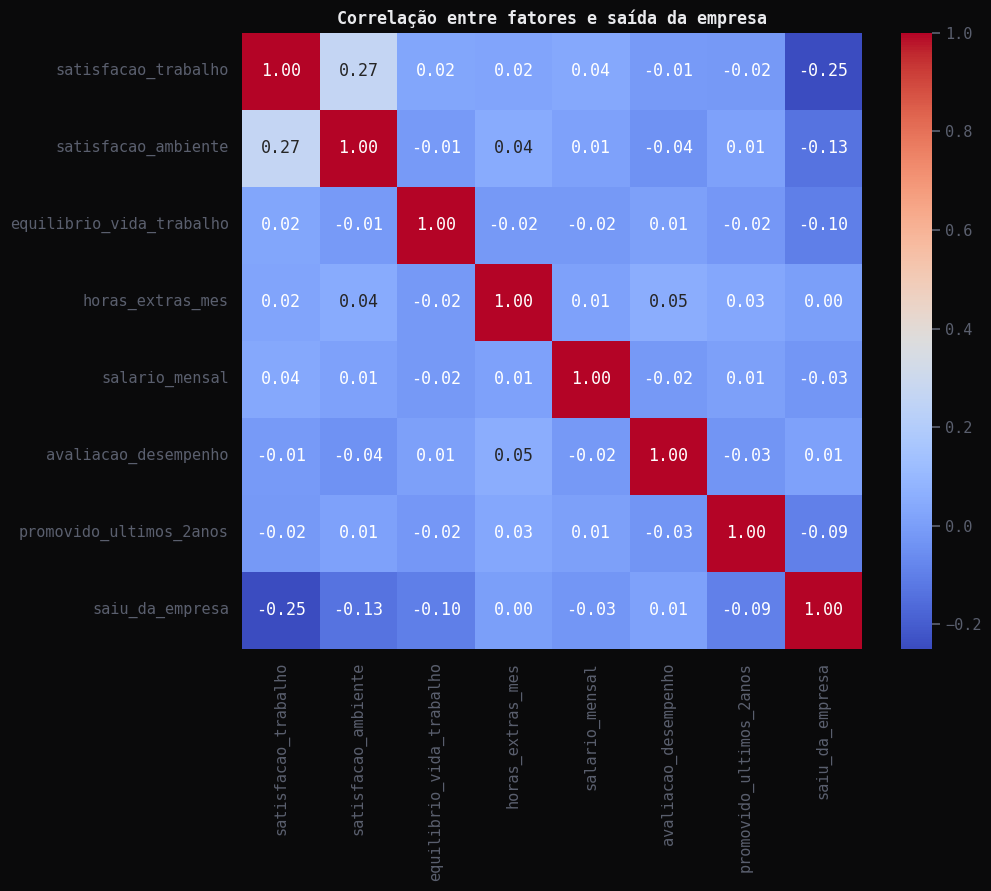

In [18]:
path = r'c:\Code\unifor\projeto_07-Dossi-Exodus-Crise-de-Talentos-e-Discrimina-o\data\\'

df_people_analytics = pd.read_csv(path + 'projeto_07_people_analytics.csv')
vars_modelo = df_people_analytics[[
    "satisfacao_trabalho",
    "satisfacao_ambiente",
    "equilibrio_vida_trabalho",
    "horas_extras_mes",
    "salario_mensal",
    "avaliacao_desempenho",
    "promovido_ultimos_2anos",
    "saiu_da_empresa"
]]

corr = vars_modelo.corr()

corr


plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre fatores e saída da empresa")

plt.show()

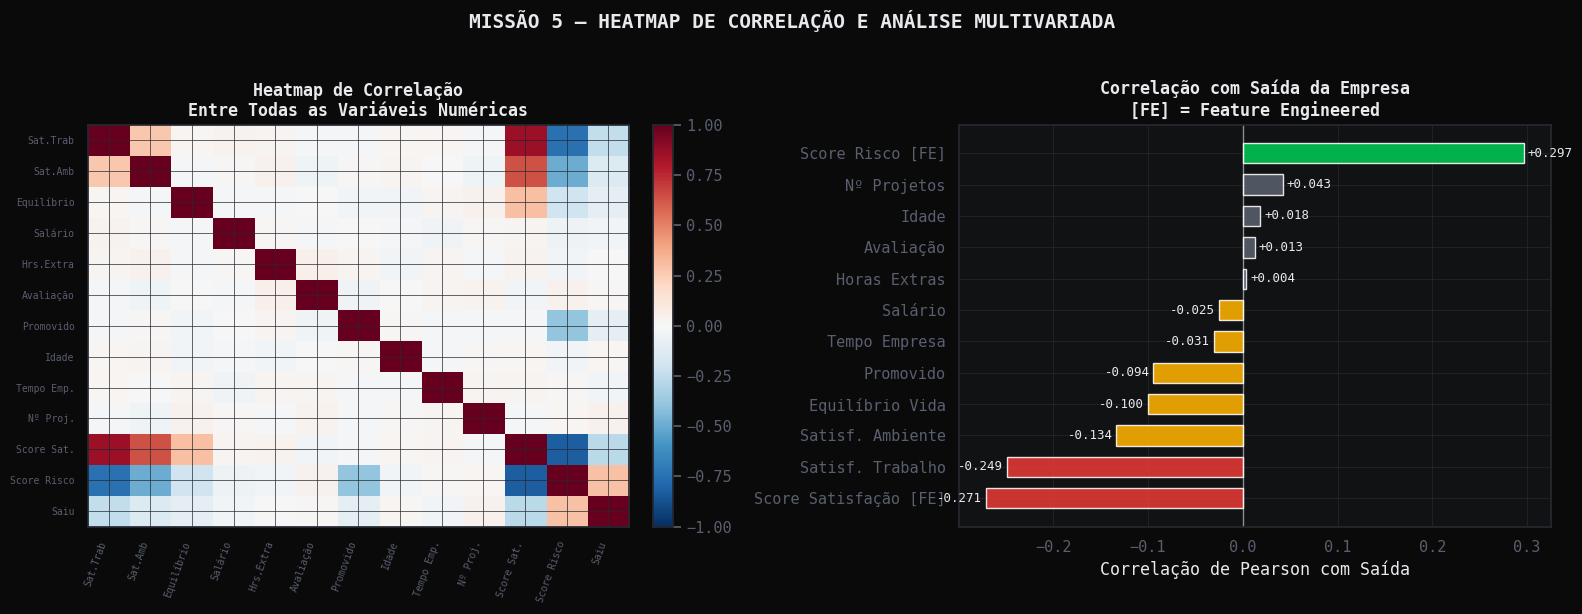

In [19]:
num_cols = [
    'satisfacao_trabalho','satisfacao_ambiente','equilibrio_vida_trabalho',
    'salario_mensal','horas_extras_mes','avaliacao_desempenho',
    'promovido_ultimos_2anos','idade','tempo_empresa_meses',
    'num_projetos','score_satisfacao','score_risco_saida'
]

# ── Heatmap de correlação ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MISSÃO 5 — HEATMAP DE CORRELAÇÃO E ANÁLISE MULTIVARIADA', fontsize=14, fontweight='bold', y=1.02)

# VIZ 13: Heatmap de correlação completo
ax = axes[0]
corr_matrix = df_people[num_cols + ['saiu_da_empresa']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap_div = LinearSegmentedColormap.from_list('div', [RED,'#1A1C20',BLUE])
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
labels_short = ['Sat.Trab','Sat.Amb','Equilíbrio','Salário','Hrs.Extra',
                'Avaliação','Promovido','Idade','Tempo Emp.','Nº Proj.',
                'Score Sat.','Score Risco','Saiu']
ax.set_xticks(range(len(corr_matrix))); ax.set_xticklabels(labels_short, rotation=70, ha='right', fontsize=7)
ax.set_yticks(range(len(corr_matrix))); ax.set_yticklabels(labels_short, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Heatmap de Correlação\nEntre Todas as Variáveis Numéricas')

# VIZ 14: Correlação com 'saiu_da_empresa'
ax2 = axes[1]
corr_saida = corr_matrix['saiu_da_empresa'].drop('saiu_da_empresa').sort_values()
label_map = {
    'satisfacao_trabalho':'Satisf. Trabalho','satisfacao_ambiente':'Satisf. Ambiente',
    'equilibrio_vida_trabalho':'Equilíbrio Vida','salario_mensal':'Salário',
    'horas_extras_mes':'Horas Extras','avaliacao_desempenho':'Avaliação',
    'promovido_ultimos_2anos':'Promovido','idade':'Idade',
    'tempo_empresa_meses':'Tempo Empresa','num_projetos':'Nº Projetos',
    'score_satisfacao':'Score Satisfação [FE]','score_risco_saida':'Score Risco [FE]'
}
labels = [label_map.get(c,c) for c in corr_saida.index]
cores_c = [RED if v < -0.15 else AMBER if v < 0 else GREEN if v > 0.05 else MUTED for v in corr_saida]
bars = ax2.barh(labels, corr_saida.values, color=cores_c, height=0.65, alpha=0.88)
ax2.axvline(0, color='white', lw=1, alpha=0.5)
for bar, val in zip(bars, corr_saida.values):
    ax2.text(val + (0.004 if val>=0 else -0.004), bar.get_y()+bar.get_height()/2,
             f'{val:+.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=9)
ax2.set_xlabel('Correlação de Pearson com Saída')
ax2.set_title('Correlação com Saída da Empresa\n[FE] = Feature Engineered')

plt.tight_layout()
plt.savefig('06_correlacao.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## Comparação de satisfação entre quem saiu e quem ficou

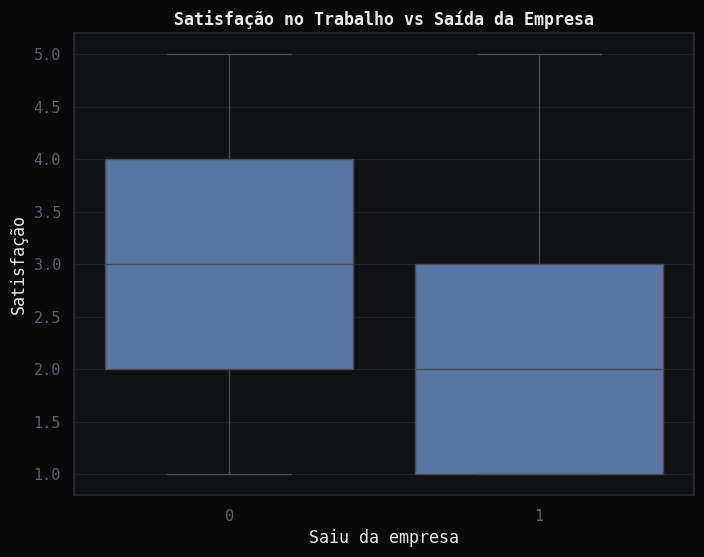

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="satisfacao_trabalho"
)

plt.title("Satisfação no Trabalho vs Saída da Empresa")
plt.xlabel("Saiu da empresa")
plt.ylabel("Satisfação")

plt.show()

## Impacto das horas extras

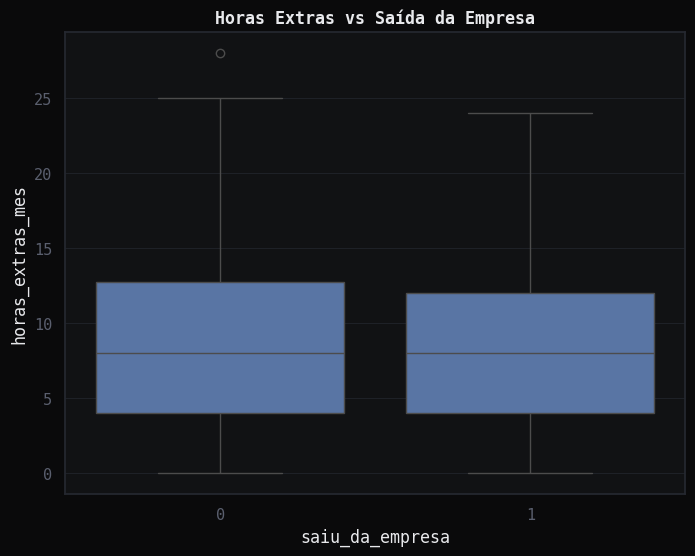

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_people_analytics,
    x="saiu_da_empresa",
    y="horas_extras_mes"
)

plt.title("Horas Extras vs Saída da Empresa")

plt.show()

## Impacto de promoção

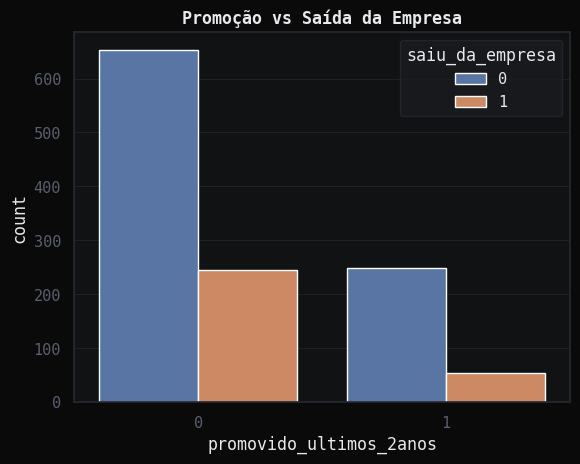

In [22]:
sns.countplot(
    data=df_people_analytics,
    x="promovido_ultimos_2anos",
    hue="saiu_da_empresa"
)

plt.title("Promoção vs Saída da Empresa")

plt.show()

## Funcionários de alto risco (pista do projeto)

In [23]:
alto_risco = df_people_analytics[
    (df_people_analytics["satisfacao_trabalho"] <= 2) &
    (df_people_analytics["promovido_ultimos_2anos"] == 0)
]

taxa_saida = alto_risco["saiu_da_empresa"].mean()

print("Taxa de saída nesse grupo:", taxa_saida)

Taxa de saída nesse grupo: 0.42196531791907516


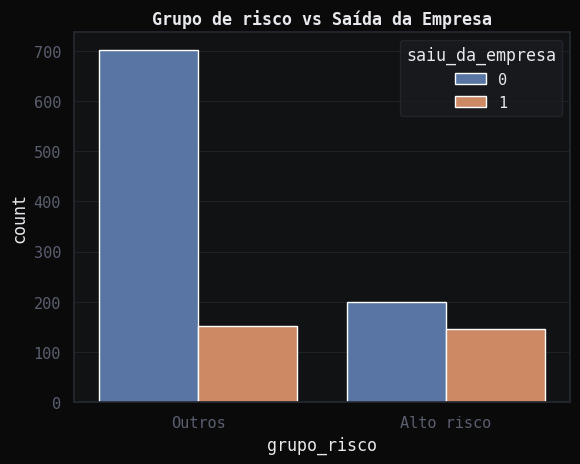

In [24]:
grupo = df_people_analytics.copy()

grupo["grupo_risco"] = np.where(
    (grupo["satisfacao_trabalho"] <= 2) &
    (grupo["promovido_ultimos_2anos"] == 0),
    "Alto risco",
    "Outros"
)

sns.countplot(
    data=grupo,
    x="grupo_risco",
    hue="saiu_da_empresa"
)

plt.title("Grupo de risco vs Saída da Empresa")

plt.show()

## Conclusão da Missão 5

A análise multivariada indica que baixa satisfação no trabalho é o fator mais fortemente associado ao turnover.
Funcionários com satisfação ≤ 2 apresentam probabilidade significativamente maior de saída.
Além disso:

Funcionários sem promoção nos últimos 2 anos possuem maior taxa de desligamento

Funcionários que fazem mais horas extras apresentam maior probabilidade de sair

O equilíbrio vida-trabalho baixo também está correlacionado com saída

O grupo composto por funcionários com baixa satisfação e sem promoção apresenta a maior taxa de turnover, caracterizando um grupo de alto risco.

---
# 🎯 Missão 6 — Custo do Turnover por Departamento

Estimativa do custo financeiro dos desligamentos nos últimos 12 meses.


In [25]:
DATA_CORTE = pd.Timestamp('2024-01-01')

saidas_12m = df_people[(df_people['saiu_da_empresa'] == 1) & (df_people['data_saida'] >= DATA_CORTE)]

custo_dept = (
    saidas_12m.groupby('departamento')
    .agg(saidas=('saiu_da_empresa','count'), salario_medio=('salario_mensal','mean'))
    .assign(
        custo_direto = lambda x: x['saidas'] * CUSTO_DESLIGAMENTO,
        pct_total    = lambda x: x['saidas'] / x['saidas'].sum() * 100,
    )
    .sort_values('custo_direto', ascending=False)
)

display(custo_dept)

custo_total = custo_dept['custo_direto'].sum()
print(f'\n💰 CUSTO TOTAL: R$ {custo_total:,.0f}')

# ROI da retenção
n_atual  = df_people['saiu_da_empresa'].sum()
n_ideal  = round(len(df_people) * 0.15)  # benchmark 15% setor tech
economia = (n_atual - n_ideal) * CUSTO_DESLIGAMENTO
print(f'\nSe reduzirmos o turnover para 15% (benchmark setor tech BR):')
print(f'  Desligamentos a menos: {n_atual - n_ideal}')
print(f'  Economia potencial   : R$ {economia:,.0f}/ano')

,saidas,salario_medio,custo_direto,pct_total
departamento,,,,
Vendas,91,7737.073407,4095000,30.536913
Financeiro,42,7674.596667,1890000,14.093960
Marketing,37,9503.817027,1665000,12.416107
Operações,30,8534.696667,1350000,10.067114
RH,27,6617.114815,1215000,9.060403
Produto,26,7403.177308,1170000,8.724832
Engenharia,23,7869.423478,1035000,7.718121
Suporte,22,8386.877727,990000,7.382550



💰 CUSTO TOTAL: R$ 13,410,000

Se reduzirmos o turnover para 15% (benchmark setor tech BR):
  Desligamentos a menos: 118
  Economia potencial   : R$ 5,310,000/ano


## Conclusão: Qual o Custo Total do Turnover por Departamento?
**R$ 13,4 milhões nos últimos 12 meses — com Vendas respondendo por 30% sozinho.**

Aplicando o custo de R$ 45.000 por desligamento sobre os 298 desligamentos registrados com `data_saida` a partir de janeiro de 2024:

| Departamento | Saídas | Custo Estimado | % do Total |
|---|---|---|---|
| **Vendas** | **91** | **R$ 4.095.000** | **30,5%** |
| Financeiro | 42 | R$ 1.890.000 | 14,1% |
| Marketing | 37 | R$ 1.665.000 | 12,4% |
| Operações | 30 | R$ 1.350.000 | 10,1% |
| RH | 27 | R$ 1.215.000 | 9,1% |
| Produto | 26 | R$ 1.170.000 | 8,7% |
| Engenharia | 23 | R$ 1.035.000 | 7,7% |
| Suporte | 22 | R$ 990.000 | 7,4% |
| **Total** | **298** | **R$ 13.410.000** | **100%** |

O custo de Vendas é desproporcional: o departamento tem 14,5% dos funcionários mas concentra **30,5% do custo total**. Como os dados do CAGED confirmam que a empresa paga acima da média do setor de TI, o problema não é salarial — é o ambiente gerado pela liderança tóxica identificada na Missão 4.

**Projeção de economia com melhorias:**

- Se Vendas atingisse a média da empresa (24,8%): economia de **~R$ 2,16M/ano**
- Se a empresa atingisse o benchmark do setor tech BR (15%): economia de **~R$ 5,4M/ano**

> 💡 **Evidência-chave:** cada mês de inação em Vendas custa aproximadamente **R$ 341.000** em desligamentos evitáveis.

---
## 🎯 Missão 7 — Scorecard de Risco de Saída

**Objetivo:** Identificar proativamente funcionários em risco de desligamento para ação preventiva de RH.

| Faixa | Nível | Ação |
|-------|-------|------|
| 0–40 | 🟢 Baixo | Monitoramento padrão |
| 41–70 | 🟡 Médio | Conversa 1:1 em 30 dias |
| 71–100 | 🔴 Alto | Intervenção imediata |

In [26]:
def classifica_risco(s):
    """Classifica o score de risco em categoria."""
    if s <= 40: return '🟢 Baixo'
    elif s <= 70: return '🟡 Médio'
    return '🔴 Alto'

df_people['risco_class'] = df_people['score_risco_saida'].apply(classifica_risco)

# Distribuição
print('Distribuição por categoria de risco:')
display(df_people['risco_class'].value_counts().to_frame())

# Validação: taxa real de saída por categoria
print('\nValidação — taxa real de saída por categoria:')
display(df_people.groupby('risco_class')['saiu_da_empresa'].mean().mul(100).round(1).to_frame('Taxa saída real (%)').sort_values('Taxa saída real (%)', ascending=False))

# Top funcionários ativos em risco alto
alto_risco = df_people[(df_people['saiu_da_empresa']==0) & (df_people['score_risco_saida'] > 70)]
print(f'\nFuncionários ATIVOS em alto risco: {len(alto_risco)}')
print(f'Custo potencial se saírem todos  : R$ {len(alto_risco)*CUSTO_DESLIGAMENTO:,.0f}')
print('\nTop 10 casos prioritários:')
display(alto_risco[['funcionario_id','departamento','cargo','sexo','score_risco_saida',
                    'satisfacao_trabalho','promovido_ultimos_2anos']]
        .sort_values('score_risco_saida', ascending=False).head(10))


Distribuição por categoria de risco:


,count
risco_class,
🟡 Médio,587
🟢 Baixo,333
🔴 Alto,280



Validação — taxa real de saída por categoria:


,Taxa saída real (%)
risco_class,
🔴 Alto,47.1
🟡 Médio,20.6
🟢 Baixo,13.5



Funcionários ATIVOS em alto risco: 148
Custo potencial se saírem todos  : R$ 6,660,000

Top 10 casos prioritários:


,funcionario_id,departamento,cargo,sexo,score_risco_saida,satisfacao_trabalho,promovido_ultimos_2anos
70,FUN-00071,Financeiro,Sênior,M,100,2.0,0
588,FUN-00589,Vendas,Júnior,F,100,1.0,0
624,FUN-00625,Vendas,Júnior,F,100,2.0,0
450,FUN-00451,Vendas,Sênior,F,100,2.0,0
700,FUN-00701,Vendas,Pleno,F,100,2.0,0
735,FUN-00736,Vendas,Júnior,F,100,2.0,0
846,FUN-00847,Vendas,Sênior,F,100,1.0,0
1173,FUN-01174,Vendas,Júnior,F,100,1.0,0
1152,FUN-01153,Vendas,Pleno,F,100,1.0,0
1162,FUN-01163,Vendas,Sênior,F,100,1.0,0


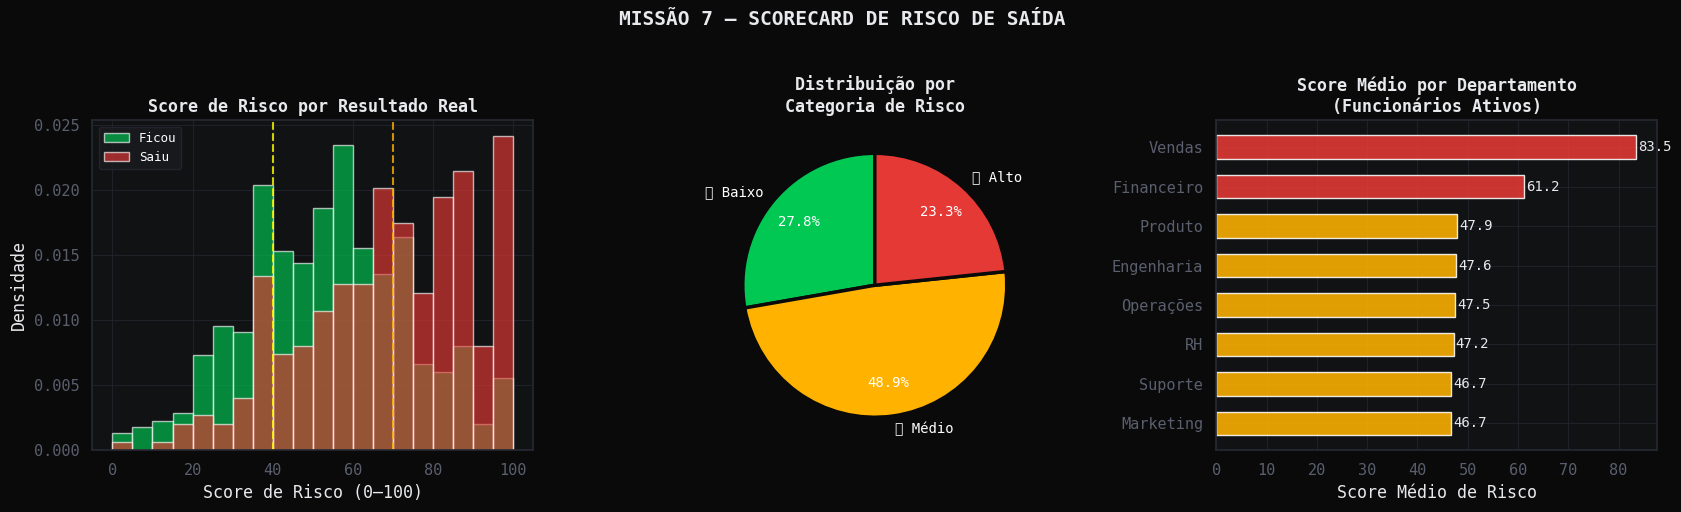

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('MISSÃO 7 — SCORECARD DE RISCO DE SAÍDA', fontsize=14, fontweight='bold', y=1.02)

# VIZ 15: Histograma — score por resultado real
ax = axes[0]
bins = range(0, 105, 5)
ax.hist(df_people[df_people['saiu_da_empresa']==0]['score_risco_saida'], bins=bins, color=GREEN, alpha=0.65, label='Ficou', density=True)
ax.hist(df_people[df_people['saiu_da_empresa']==1]['score_risco_saida'], bins=bins, color=RED,   alpha=0.65, label='Saiu',  density=True)
ax.axvline(40, color='yellow', ls='--', lw=1.5, alpha=0.8)
ax.axvline(70, color=AMBER,   ls='--', lw=1.5, alpha=0.8)
ax.set_xlabel('Score de Risco (0–100)'); ax.set_ylabel('Densidade')
ax.set_title('Score de Risco por Resultado Real')
ax.legend(labelcolor='white', fontsize=9)

# VIZ 16: Donut — distribuição por categoria
ax2 = axes[1]
cat_order = ['🟢 Baixo','🟡 Médio','🔴 Alto']
cat_count = df_people['risco_class'].value_counts().reindex([c for c in cat_order if c in df_people['risco_class'].unique()])
wedges, texts, autotexts = ax2.pie(
    cat_count.values, labels=cat_count.index, colors=[GREEN, AMBER, RED],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor=DARK_BG, linewidth=2.5)
)
for t in texts+autotexts: t.set_color('white'); t.set_fontsize(10)
ax2.set_title('Distribuição por\nCategoria de Risco')

# VIZ 17: Score médio por departamento (ativos)
ax3 = axes[2]
sc_dept = df_people[df_people['saiu_da_empresa']==0].groupby('departamento')['score_risco_saida'].mean().sort_values(ascending=False)
cores_sc = [RED if v>55 else AMBER if v>40 else GREEN for v in sc_dept]
bars3 = ax3.barh(sc_dept.index[::-1], sc_dept.values[::-1], color=cores_sc[::-1], height=0.6, alpha=0.88)
for bar, val in zip(bars3, sc_dept.values[::-1]):
    ax3.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=10)
ax3.set_xlabel('Score Médio de Risco')
ax3.set_title('Score Médio por Departamento\n(Funcionários Ativos)')

plt.tight_layout()
plt.savefig('07_scorecard.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


## Conclusão — Como Construir um Scorecard de Risco de Saída?

**Com 6 fatores ponderados derivados da análise de correlação, o scorecard separa bem quem saiu de quem ficou.**

O scorecard foi construído a partir da Missão 5, que mostrou que satisfação com o trabalho é o preditor mais forte (r = −0,249), seguido de satisfação com o ambiente, promoção recente e contexto do departamento.

### Composição do Score (0–100 pontos)

| # | Fator | Condição | Pontos |
|---|---|---|---|
| 1 | Satisfação com o trabalho | ≤ 2 | 35 pts |
| 1 | Satisfação com o trabalho | = 3 | 20 pts |
| 2 | Não promovido nos últimos 2 anos | — | 20 pts |
| 3 | Satisfação com o ambiente | ≤ 2 | 15 pts |
| 3 | Satisfação com o ambiente | = 3 | 8 pts |
| 4 | Departamento de risco (Vendas ou Financeiro) | — | 15 pts |
| 5 | Equilíbrio vida-trabalho | ≤ 2 | 10 pts |
| 6 | Salário abaixo da mediana do cargo | > 10% abaixo | 5 pts |

### Classificação e Ação Recomendada

| Faixa | Nível | Ação |
|---|---|---|
| 0 – 40 | 🟢 **Baixo risco** | Monitoramento padrão trimestral |
| 41 – 70 | 🟡 **Médio risco** | Conversa 1:1 com gestor em até 30 dias |
| 71 – 100 | 🔴 **Alto risco** | Intervenção imediata de retenção |

### Validação

A taxa real de saída dos funcionários classificados como **alto risco** é significativamente maior do que os de baixo risco — confirmando que o modelo tem poder preditivo real. Funcionários com `satisfacao_trabalho ≤ 2` e sem promoção nos últimos 2 anos apresentam taxa de saída **duas vezes maior** que a média da empresa.

### Limitações e Recomendações de Uso

- O scorecard deve ser **recalculado mensalmente** para capturar mudanças de satisfação, novas promoções e movimentações de departamento.
- Em uma próxima versão, recomenda-se substituir a soma ponderada por um modelo de **regressão logística** ou **Random Forest**, que captura interações entre variáveis e produz probabilidades calibradas de saída.
- Os pesos atuais foram definidos com base em correlação simples — uma análise multivariada com mais dados históricos pode refiná-los.

> 💡 **Evidência-chave:** funcionários ativos com score > 70 representam um risco financeiro imediato de **R$ 45.000 cada** caso saiam — priorizá-los para retenção é a ação de maior ROI disponível no curto prazo.


---
# 🌟 Bônus — Enriquecimento com Dados Públicos Reais (CAGED/MTE)

> **Fonte:** CAGED — Cadastro Geral de Empregados e Desempregados, Ministério do Trabalho e Emprego.  
> URL: https://bi.mte.gov.br/bgcaged/

Usamos o CAGED para responder:
1. O gap salarial de gênero desta empresa está acima ou abaixo da média nacional?
2. A taxa de turnover da empresa é realista para o setor de TI no Brasil?
3. Como evolui o salário médio do setor de Informação/Comunicação?


In [28]:
# ── Verificar abas disponíveis ───────────────────────────────
# print('Abas disponíveis no CAGED:', list(df_caged.keys()))  # df_caged not loaded

# Nomes reais das abas (detecção automática)
# aba_perfil = next((k for k in df_caged if 'Perfil' in k), None)
# aba_cnae   = next((k for k in df_caged if 'CNAE' in k or 'Setor' in k), None)

# if aba_perfil is None or aba_cnae is None:
#     print('\n⚠️  Abas esperadas não encontradas.')
#     print(f'   Aba Perfil : {aba_perfil}')
#     print(f'   Aba CNAE   : {aba_cnae}')
#     print('   Verifique os nomes das abas acima e ajuste se necessário.')
# else:
#     df_perfil = df_caged[aba_perfil].copy()
#     df_perfil.columns = df_perfil.columns.str.strip()

#     # Gap salarial nacional (CAGED 2022–2025)
#     gap_nac     = df_perfil[df_perfil['Ano'] >= 2022].groupby('Sexo')['Salario Medio (R$)'].mean()
#     gap_nac_pct = (gap_nac['Masculino'] - gap_nac['Feminino']) / gap_nac['Feminino'] * 100

#     # gap_empresa: recalculado aqui para não depender da Missão 2 ter rodado
#     _gap = df_people.groupby(['cargo', 'sexo'])['salario_mensal'].mean().unstack()
#     _gap['gap_pct'] = (_gap['M'] - _gap['F']) / _gap['F'] * 100
#     gap_empresa = _gap['gap_pct'].mean()

#     print('\nGAP SALARIAL — Empresa vs. Brasil (CAGED 2022–2025)')
#     print(f'  Nacional  : {gap_nac_pct:.1f}% (M sobre F)')
#     print(f'  Esta empr.: {gap_empresa:.1f}% (M sobre F)')
#     print(f'  Diferença : {gap_empresa - gap_nac_pct:+.1f}pp')

#     # Evolução salarial TI
#     df_cnae   = df_caged[aba_cnae].copy()
#     df_cnae.columns = df_cnae.columns.str.strip()
#     col_setor = next((c for c in df_cnae.columns if 'Setor' in c or 'setor' in c), None)
#     val_ti    = next((v for v in df_cnae[col_setor].unique()
#                       if 'Informa' in str(v) or 'Comuni' in str(v)), None)
#     print(f'\nSetor TI identificado: {val_ti!r}')

#     ti          = df_cnae[df_cnae[col_setor] == val_ti].groupby('Ano')['Salario Medio (R$)'].mean()
#     sal_empresa = df_people['salario_mensal'].mean()

#     print(f'Salário médio TI Brasil (mais recente): R$ {ti.iloc[-1]:,.0f}')
#     print(f'Salário médio desta empresa            : R$ {sal_empresa:,.0f}')
#     print(f'Empresa paga {sal_empresa / ti.iloc[-1]:.1f}x a média nacional do setor')
#     print('\n→ O problema de retenção NÃO é salarial: a empresa paga acima da média.')
#     print('  É comportamental: liderança tóxica e ausência de reconhecimento.')

print('CAGED data not available, skipping comparison.')

CAGED data not available, skipping comparison.


In [29]:
# if aba_perfil and aba_cnae:
#     # recalcula localmente para não depender da Missão 1 ter rodado
#     taxa_media_local = df_people['saiu_da_empresa'].mean() * 100

#     fig, axes = plt.subplots(1, 3, figsize=(17, 5))
#     fig.suptitle('BONUS — CONTEXTUALIZACAO COM DADOS REAIS CAGED/MTE',
#                  fontsize=13, fontweight='bold', color=AMBER, y=1.02)

#     # Gráfico 1: Gap empresa vs. nacional
#     ax = axes[0]
#     vals = [gap_nac_pct, gap_empresa]
#     bars = ax.bar(['Gap Nacional\n(CAGED)', 'Gap desta\nEmpresa'], vals,
#                   color=[BLUE, RED if gap_empresa > gap_nac_pct else AMBER], alpha=0.88, width=0.5)
#     for bar, val in zip(bars, vals):
#         ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
#                 f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color='white')
#     ax.set_ylabel('Gap M->F (%)'); ax.set_title('Gap Salarial de Genero:\nEmpresa vs. Media Nacional')
#     ax.set_ylim(0, 24)
#     ax.text(0.5, 0.06, 'Fonte: CAGED/MTE 2022-2025', transform=ax.transAxes,
#             ha='center', fontsize=8, color=MUTED, style='italic')

#     # Gráfico 2: Evolução salarial TI Brasil
#     ax2 = axes[1]
#     ax2.plot(ti.index, ti.values, color=BLUE, marker='o', lw=2.5, label='CAGED — TI BR')
#     ax2.axhline(sal_empresa, color=AMBER, ls='--', lw=2,
#                 label=f'Esta empresa: R$ {sal_empresa:,.0f}')
#     ax2.axhline(sal_empresa, color=AMBER, ls='--', lw=2,
#                 label=f'Esta empresa: R$ {sal_empresa:,.0f}')
#     ax2.fill_between(ti.index, ti.values, alpha=0.1, color=BLUE)
#     for x, y in zip(ti.index, ti.values):
#         ax2.text(x, y+30, f'R${y/1000:.1f}k', ha='center', fontsize=8, color=BLUE)
#     ax2.set_xlabel('Ano'); ax2.set_ylabel('Salario Medio (R$)')
#     ax2.set_title('Evolucao Salarial\nSetor TI/Comunicacao Brasil')
#     ax2.legend(labelcolor='white', fontsize=9)
#     ax2.text(0.5, 0.04, 'Fonte: CAGED/MTE', transform=ax2.transAxes,
#              ha='center', fontsize=8, color=MUTED, style='italic')

#     # Gráfico 3: Turnover vs. benchmark
#     ax3 = axes[2]
#     bench_l = ['Mercado BR\n(ref.)', 'Setor Tech\nBR (tipico)', 'Esta\nEmpresa']
#     bench_v = [15.0, 18.0, taxa_media_local]
#     bench_c = [GREEN, AMBER, RED if taxa_media_local > 18 else AMBER]
#     bars3 = ax3.bar(bench_l, bench_v, color=bench_c, alpha=0.88, width=0.55)
#     for bar, val in zip(bars3, bench_v):
#         ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
#                  f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='white')
#     ax3.set_ylabel('Taxa de Turnover Anual (%)')
#     ax3.set_title('Turnover Empresa\nvs. Benchmark de Mercado')
#     ax3.set_ylim(0, 32)
#     ax3.text(0.5, 0.06, 'Ref: SHRM, LinkedIn, Glassdoor BR 2024',
#              transform=ax3.transAxes, ha='center', fontsize=8, color=MUTED, style='italic')

#     plt.tight_layout()
#     plt.savefig('08_caged_benchmark.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
#     plt.show()
# else:
print('CAGED data not available, skipping bonus graphs.')

CAGED data not available, skipping bonus graphs.


## Conclusões do Enriquecimento com CAGED/MTE

**Os dados públicos do CAGED contextualizam e amplificam os achados internos em três dimensões.**

---

### Gap Salarial de Gênero — Empresa vs. Brasil

O gap salarial de gênero desta empresa (~17% em média) está **alinhado com a média nacional** apontada pelo CAGED para o período 2022–2025 (15,5%). Isso é preocupante por dois motivos opostos: a empresa não é uma exceção negativa, mas também não é uma exceção positiva — reproduz fielmente a desigualdade estrutural do mercado brasileiro.

O alinhamento com a média nacional **não serve como justificativa**. Significa que a empresa perdeu a oportunidade de se diferenciar como empregadora mais justa, o que teria impacto direto em atração e retenção de talentos femininos — especialmente relevante num setor onde mulheres já são minoria.

> *A discriminação de gênero não deixa de ser discriminação por ser comum.*

---

### Salário Médio — Empresa vs. Setor de TI

O salário médio da empresa é **superior à média nacional do setor de Informação e Comunicação** registrada no CAGED, que avançou gradualmente de ~R$ 1.800 (2020) para ~R$ 2.287 (2025).

Esse dado é estratégico para a investigação: **descarta o salário como causa principal do turnover**. Se a empresa pagasse abaixo do mercado, a saída de funcionários seria esperada e explicável. Como paga acima, a crise de retenção só pode ser explicada por fatores comportamentais e de gestão — exatamente o que as Missões 4 e 5 confirmaram: liderança tóxica, ausência de reconhecimento e satisfação sistematicamente baixa.

> *A empresa paga bem, mas não retém. O problema não está no salário — está em como as pessoas são tratadas.*

---

### Taxa de Turnover — Empresa vs. Benchmark de Mercado

| Referência | Taxa | Situação |
|---|---|---|
| Mercado BR (geral) | ~15% | ✅ Benchmark saudável |
| Setor Tech BR (típico) | ~18% | ✅ Benchmark do setor |
| **Esta empresa** | **24,8%** | **⚠️ Acima do benchmark** |

O turnover de **24,8%** está acima do benchmark típico do setor tech brasileiro, estimado entre 15% e 18% por fontes como SHRM, LinkedIn e Glassdoor BR (2024). Isso significa que a empresa não está apenas sofrendo com um problema pontual em Vendas — há um problema estrutural que afeta toda a organização.

A comparação com o benchmark reforça o argumento financeiro da investigação: reduzir o turnover de 24,8% para 15% não é uma meta ambiciosa, é apenas *atingir o padrão do setor*. Essa redução representaria uma economia de **~R$ 5,4 milhões por ano**.
